In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("product_info.csv")
df.head()

,user_id,timestamp,variant,device,country,traffic_source,new_user,pages_viewed,session_duration_sec,converted,order_value,revenue
0,1,2025-02-05 20:00:00,A,Desktop,India,Social,0,5,64,1,95.05,95.05
1,2,2025-06-07 04:00:00,A,Desktop,India,Social,1,9,206,0,0.00,0.00
2,3,2025-05-09 20:00:00,B,Desktop,USA,Organic,1,9,226,0,0.00,0.00
3,4,2025-01-20 10:00:00,A,Desktop,India,Organic,1,7,154,0,0.00,0.00
4,5,2025-05-24 12:00:00,A,Desktop,UK,Organic,1,4,116,0,0.00,0.00


In [6]:
total_users = len(df)

print("Total Users:", total_users)

Total Users: 100000


In [4]:
device_counts = df["device"].value_counts()

print(device_counts)

device
Mobile     45122
Desktop    44795
Tablet     10083
Name: count, dtype: int64


In [7]:
variant_counts = df['variant'].value_counts()

print(variant_counts)

variant
B    50143
A    49857
Name: count, dtype: int64


In [8]:
variant_counts = (
    df.groupby('variant')
      .size()
      .reset_index(name='Users')
)

print(variant_counts)

  variant  Users
0       A  49857
1       B  50143


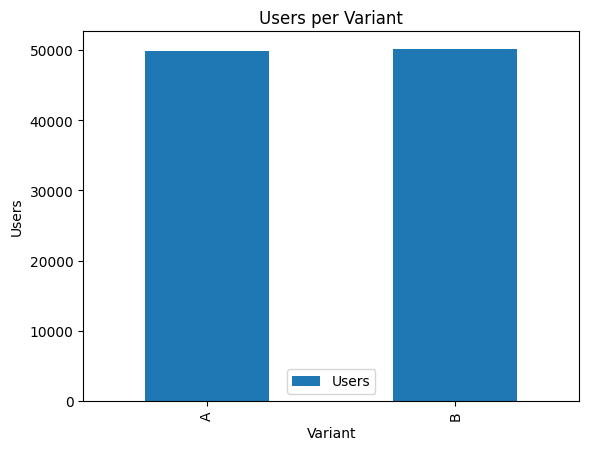

In [10]:
variant_counts.plot(
    x='variant',
    y='Users',
    kind='bar'
)

plt.title("Users per Variant")
plt.xlabel("Variant")
plt.ylabel("Users")

plt.show()

In [11]:
conversion = (
    df.groupby('variant')['converted']
      .agg(['count','sum'])
)

conversion.columns = ['Visitors','Conversions']

conversion['Conversion Rate'] = (
    conversion['Conversions']
    /
    conversion['Visitors']
)*100

print(conversion)

         Visitors  Conversions  Conversion Rate
variant                                        
A           49857         5676        11.384560
B           50143         6462        12.887143


In [3]:
print(df.columns.tolist())

['user_id', 'timestamp', 'variant', 'device', 'country', 'traffic_source', 'new_user', 'pages_viewed', 'session_duration_sec', 'converted', 'order_value', 'revenue']


In [10]:
## Which variant generated more total revenue?--

revenue = (df.groupby("variant")["revenue"].sum().reset_index())
print(revenue)

  variant    revenue
0       A  426463.18
1       B  485831.97


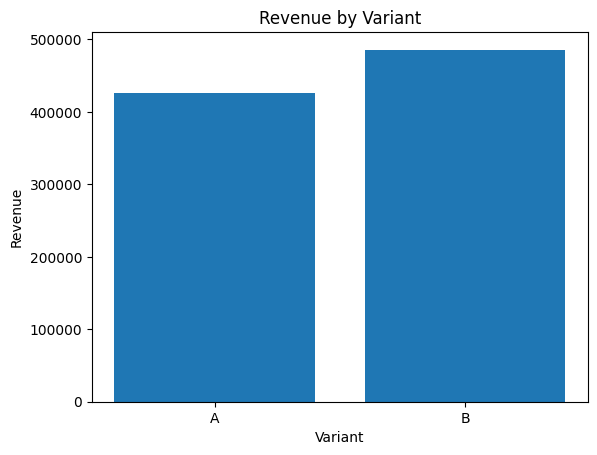

In [13]:
plt.bar(revenue['variant'],revenue['revenue'])

plt.title("Revenue by Variant")

plt.xlabel("Variant")

plt.ylabel("Revenue")

plt.show()

In [14]:
## What is the Average Order Value (AOV) for each variant?

aov = (
    df[df['converted']==1]
    .groupby('variant')['order_value']
    .mean()
    .reset_index()
)

print(aov)

  variant  order_value
0       A    75.134457
1       B    75.182911


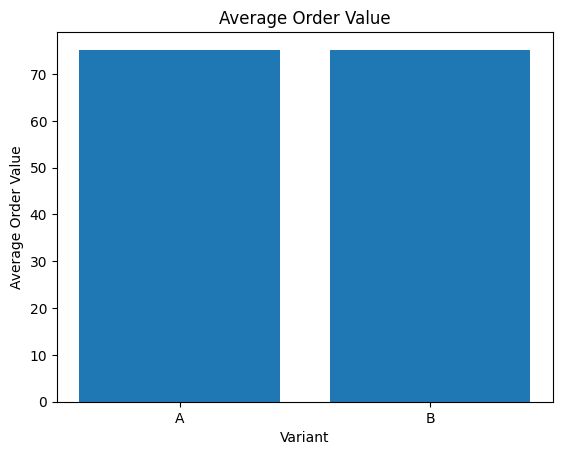

In [15]:
plt.bar(aov['variant'], aov['order_value'])

plt.title("Average Order Value")

plt.xlabel("Variant")

plt.ylabel("Average Order Value")

plt.show()

In [16]:
## What is the Average Revenue Per User (ARPU) for each variant?

arpu = (
    df.groupby("variant")["revenue"]
      .mean()
      .reset_index()
      .rename(columns={"revenue":"ARPU"})
)

print(arpu)

  variant      ARPU
0       A  8.553727
1       B  9.688929


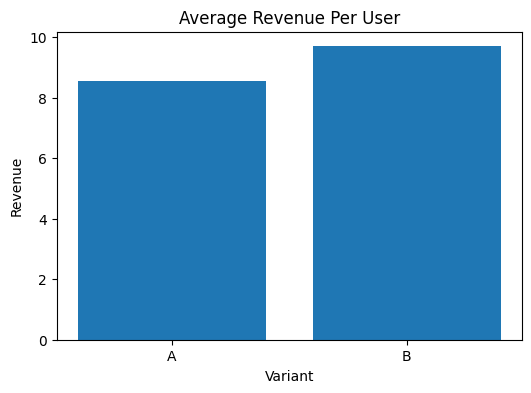

In [17]:
plt.figure(figsize=(6,4))

plt.bar(arpu["variant"], arpu["ARPU"])

plt.title("Average Revenue Per User")

plt.xlabel("Variant")
plt.ylabel("Revenue")

plt.show()

In [18]:
## Which variant produced higher conversion lift?

cr = df.groupby("variant")["converted"].mean()

cr_a = cr["A"]
cr_b = cr["B"]

lift = ((cr_b - cr_a) / cr_a) * 100

print(f"Conversion Rate A : {cr_a:.4f}")
print(f"Conversion Rate B : {cr_b:.4f}")
print(f"Lift : {lift:.2f}%")

Conversion Rate A : 0.1138
Conversion Rate B : 0.1289
Lift : 13.20%


In [19]:
## Which device has the highest conversion rate?

device_conversion = (
    df.groupby("device")["converted"]
      .mean()
      .reset_index()
)

device_conversion["Conversion Rate (%)"] = (
    device_conversion["converted"] * 100
)

print(device_conversion)

    device  converted  Conversion Rate (%)
0  Desktop   0.127068            12.706775
1   Mobile   0.117149            11.714906
2   Tablet   0.115045            11.504513


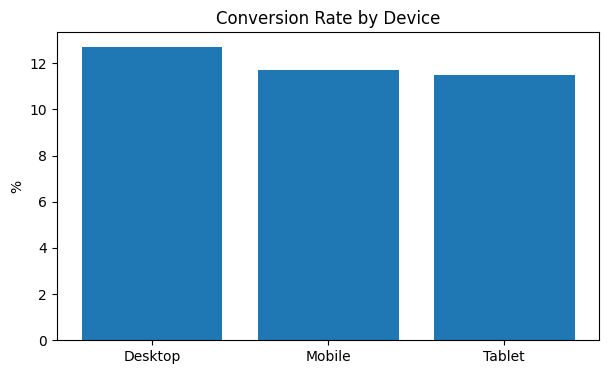

In [20]:
plt.figure(figsize=(7,4))

plt.bar(
    device_conversion["device"],
    device_conversion["Conversion Rate (%)"]
)

plt.title("Conversion Rate by Device")

plt.ylabel("%")

plt.show()

In [21]:
## Which country has the highest conversion rate?

country_conversion = (
    df.groupby("country")["converted"]
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

country_conversion["Conversion Rate (%)"] = (
    country_conversion["converted"] * 100
)

print(country_conversion)

     country  converted  Conversion Rate (%)
0  Australia   0.127128            12.712803
1         UK   0.126772            12.677224
2    Germany   0.121297            12.129704
3     Canada   0.121246            12.124583
4        USA   0.120670            12.067017
5      India   0.117865            11.786516


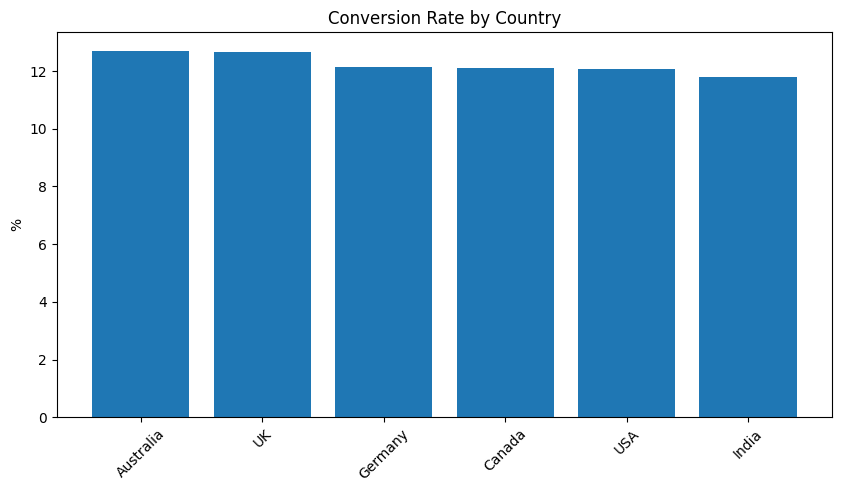

In [22]:
plt.figure(figsize=(10,5))

plt.bar(
    country_conversion["country"],
    country_conversion["Conversion Rate (%)"]
)

plt.xticks(rotation=45)

plt.ylabel("%")

plt.title("Conversion Rate by Country")

plt.show()

In [23]:
## Which traffic source converts the best?

traffic = (
    df.groupby("traffic_source")["converted"]
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

traffic["Conversion Rate (%)"] = (
    traffic["converted"] * 100
)

print(traffic)

  traffic_source  converted  Conversion Rate (%)
0          Email   0.136700            13.669967
1       Referral   0.120980            12.097994
2         Social   0.120504            12.050444
3        Organic   0.118200            11.820033
4           Paid   0.117227            11.722708


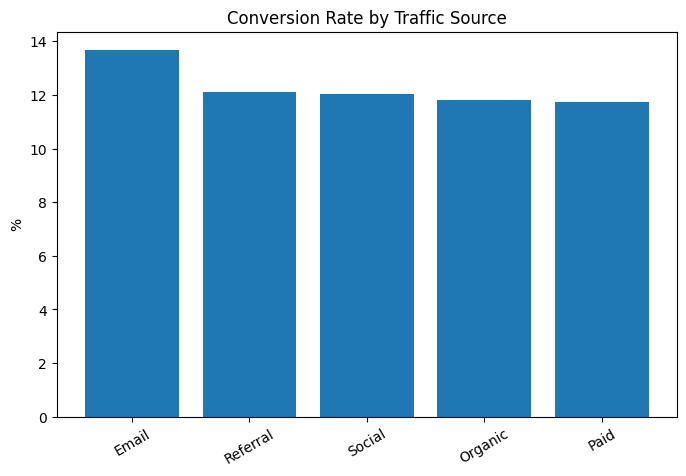

In [24]:
plt.figure(figsize=(8,5))

plt.bar(
    traffic["traffic_source"],
    traffic["Conversion Rate (%)"]
)

plt.title("Conversion Rate by Traffic Source")

plt.ylabel("%")

plt.xticks(rotation=30)

plt.show()

In [26]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

In [28]:
## Do new users convert differently than returning users?

# user_type = (
#     df.groupby("new_user")["converted"]
#       .agg(["count", "sum", "mean"])
#       .reset_index()
# )

# user_type.columns = [
#     "New User",
#     "Visitors",
#     "Conversions",
#     "Conversion Rate"
# ]

# user_type["Conversion Rate (%)"] *= 100

# user_type["New User"] = user_type["New User"].map({
#     1: "New",
#     0: "Returning"
# })

# print(user_type)

In [29]:
## What is the average session duration for each variant?

session = (
    df.groupby("variant")["session_duration_sec"]
      .mean()
      .reset_index()
)

print(session)

  variant  session_duration_sec
0       A            237.744108
1       B            238.100054


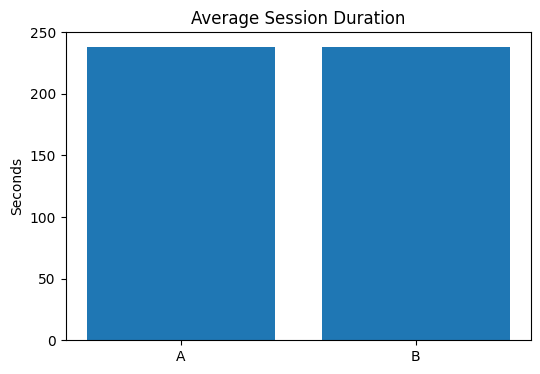

In [30]:
plt.figure(figsize=(6,4))

plt.bar(
    session["variant"],
    session["session_duration_sec"]
)

plt.title("Average Session Duration")
plt.ylabel("Seconds")

plt.show()

In [31]:
## How many pages does each variant view on average?

pages = (
    df.groupby("variant")["pages_viewed"]
      .mean()
      .reset_index()
)

print(pages)

  variant  pages_viewed
0       A      6.009106
1       B      6.007160


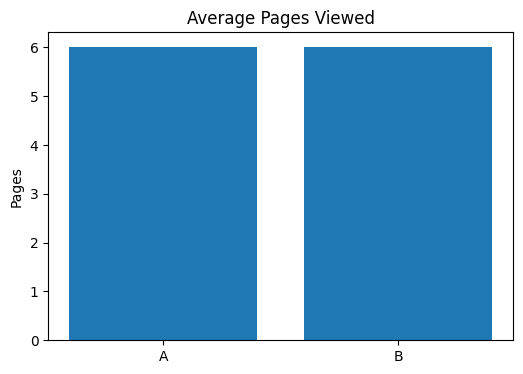

In [32]:
plt.figure(figsize=(6,4))

plt.bar(
    pages["variant"],
    pages["pages_viewed"]
)

plt.title("Average Pages Viewed")
plt.ylabel("Pages")

plt.show()

In [33]:
## What is the daily conversion rate?

df["date"] = df["timestamp"].dt.date

daily = (
    df.groupby("date")["converted"]
      .mean()
      .reset_index()
)

daily["Conversion Rate (%)"] = (
    daily["converted"] * 100
)

print(daily.head())

         date  converted  Conversion Rate (%)
0  2025-01-01   0.137324            13.732394
1  2025-01-02   0.115607            11.560694
2  2025-01-03   0.111111            11.111111
3  2025-01-04   0.120939            12.093863
4  2025-01-05   0.104129            10.412926


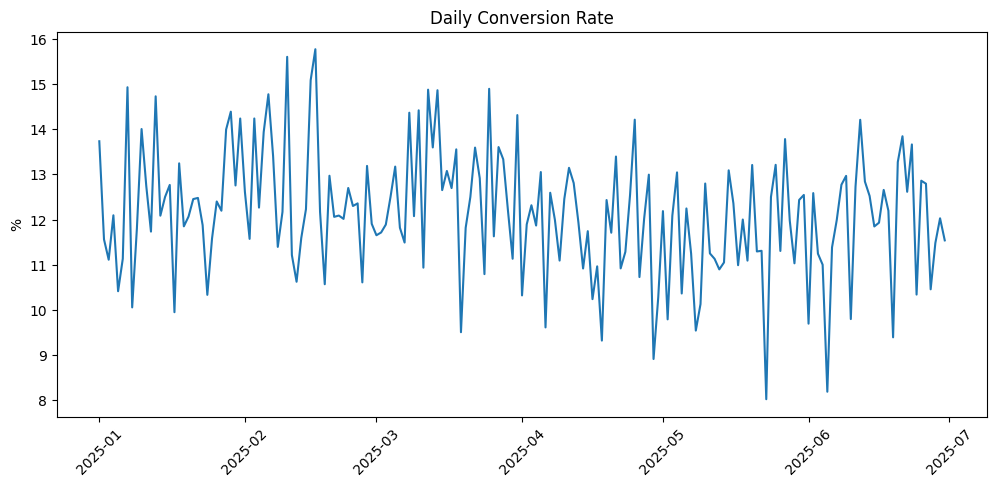

In [34]:
plt.figure(figsize=(12,5))

plt.plot(
    daily["date"],
    daily["Conversion Rate (%)"]
)

plt.xticks(rotation=45)

plt.title("Daily Conversion Rate")

plt.ylabel("%")

plt.show()

In [35]:
## How does daily revenue change over time?

daily_revenue = (
    df.groupby("date")["revenue"]
      .sum()
      .reset_index()
)

print(daily_revenue.head())

         date  revenue
0  2025-01-01  5907.00
1  2025-01-02  4346.74
2  2025-01-03  4765.05
3  2025-01-04  5406.09
4  2025-01-05  4019.98


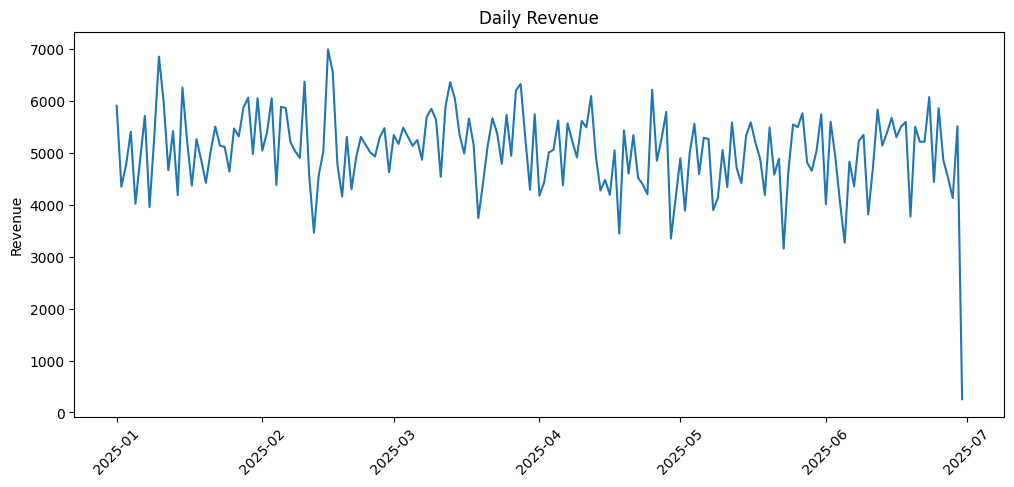

In [36]:
plt.figure(figsize=(12,5))

plt.plot(
    daily_revenue["date"],
    daily_revenue["revenue"]
)

plt.xticks(rotation=45)

plt.title("Daily Revenue")

plt.ylabel("Revenue")

plt.show()

In [37]:
from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.proportion import confint_proportions_2indep

In [38]:
## Is the traffic split between Variant A and Variant B balanced? (Sample Ratio Mismatch - SRM)

variant_counts = df["variant"].value_counts()

print(variant_counts)

variant
B    50143
A    49857
Name: count, dtype: int64


In [39]:
observed = variant_counts.values

expected = [
    observed.sum()/2,
    observed.sum()/2
]

chi2, p, dof, expected_values = chi2_contingency([observed, expected])

print("Chi-square:", chi2)
print("P-value:", p)

Chi-square: 0.40328082466895837
P-value: 0.5253997480006775


In [40]:
if p < 0.05:
    print("Sample Ratio Mismatch Detected")
else:
    print("Traffic split is balanced")

Traffic split is balanced
